In [292]:
%matplotlib inline
import htree.logger as logger
import htree.conf as conf
from htree.tree_collections import MultiTree, Tree

logger.set_logger(False, log_dir="/Users/smirarab/tmp")

In [108]:
# This is a hack for a missing function, enabling us to embed given a distance matrix directly instead of trees
from htree import utils  as utils
import htree.embedding as embedding
import os
import pickle

def embed_dist(
        dim: int, dist, labels,
        geometry: str = 'hyperbolic',
        **kwargs
    ):
    if dim is None:
        raise ValueError("Parameter 'dim' is required.")
    # Parameter defaults
    defaults = {
        'precise_opt': conf.ENABLE_ACCURATE_OPTIMIZATION, 'epochs': conf.TOTAL_EPOCHS,
        'lr_init': conf.INITIAL_LEARNING_RATE, 'dist_cutoff': conf.MAX_RANGE,
        'export_video': conf.ENABLE_VIDEO_EXPORT, 'save_mode': conf.ENABLE_SAVE_MODE,
        'scale_fn': None, 'lr_fn': None, 'weight_exp_fn': None, 'curvature': None,
    }
    params = {k: kwargs.get(k, v) for k, v in defaults.items()}
    params['save_mode'] |= params['export_video']
    params['export_video'] &= params['precise_opt']
    is_hyperbolic = geometry == 'hyperbolic'
    try:
        dist_matrix, curvature = dist, None
        # Hyperbolic: scale distances and compute curvature
        if is_hyperbolic:
            if params['curvature'] is not None and params['curvature'] >= 0:
                print("Wrong input curvature. It has to be negative.")
                return None
            if params['curvature'] is not None:
                curvature, params['scale_fn'] = params['curvature'], lambda x1, x2, x3: False
                scale = np.sqrt(-curvature)
            else:
                scale = params['dist_cutoff'] / torch.max(refdist)
                curvature = -(scale ** 2)
            dist_matrix = dist_matrix * scale
        # Naive embedding initialization
        points = utils.naive_embedding(dist_matrix, dim, geometry=geometry)
        # Precise optimization refinement
        if params['precise_opt']:
            opt_result = utils.precise_embedding(
                dist_matrix, dim, geometry=geometry, init_pts=points, **params)
            points, opt_scale = (opt_result, 1) if not is_hyperbolic else opt_result
            curvature = curvature * opt_scale ** 2 if is_hyperbolic else None
        # Construct embedding object
        result = (embedding.LoidEmbedding(points=points, labels=labels, curvature=curvature)
                  if is_hyperbolic else embedding.EuclideanEmbedding(points=points, labels=labels))
    except Exception as e:
        raise
    # Save embedding to timestamped directory
    out_dir = os.path.join(conf.OUTPUT_DIRECTORY, "test")
    os.makedirs(out_dir, exist_ok=True)
    filepath = os.path.join(out_dir, f"{geometry}_embedding_{dim}d.pkl")
    try:
        with open(filepath, 'wb') as f:
            pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
    except (IOError, pickle.PicklingError) as e:
        raise
    return result

In [277]:
# Read and embed the species trees
import subprocess
st = Tree("astral-Fig3-rooted.scored.tre")
std,ld = st.distance_matrix()
res = []
distor = []
for d in range(2,21):
    se = st.embed(dim=d, geometry='hyperbolic',precise_opt=True)
    m,l = se.distance_matrix()
    with open('se.txt','w') as f:
        f.write("%d\n%s\n" %(len(l), "\n".join("%s %s" %(l[i],"\t".join(f"{a:.6g}" for a in m[i].tolist())) for i in range(0,len(l)))))
    subprocess.run(["/Users/smirarab/miniforge3/bin/fastme", "-i", "se.txt"],capture_output=True,text=True,check=True)
    result = subprocess.run(["compareTrees.missingBranch",  "astral-Fig3-rooted.scored.tre", "se.txt_fastme_tree.nwk"],capture_output=True,text=True,check=True)
    res.append(result.stdout.split()[2])
    distor.append(float(sum(sum((m-std)**2))))
    print(distor[-1],res[-1])
with open('st-dimensions.txt','w') as f:
    f.write("Dim Distortion STERR\n%s" %("\n".join("%d %f %s" %(d,distor[d-2],res[d-2]) for d in range(2,21))))

180.16476884093663 .54
29.902806608559015 .24
16.846396733176896 .14
11.74862154790317 .11
5.226673334212184 .06
3.2506562278778706 .07
2.3499300460971733 .05
1.9133712311169717 .01
1.3959912231735656 .02
1.1276032685888828 .02
1.0877148120593831 0
1.0355578295544874 0
0.7646176445028553 .03
0.60640212413394 0
0.5817090082908017 0
0.479477400573231 0
0.44937274186945864 0
0.5262709211154339 0
0.3469026971386395 0


Fixed-point iteration: 100%|█████████████████████| 1000/1000 [00:04<00:00, 239.90it/s, residual=4.77e-07]
/var/folders/pg/_kwt84350pq9_0fgqdt079cm0000gn/T/ipykernel_49485/1430741555.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scale = np.sqrt(-curvature)


{2: [('mean', np.float64(8.1247817377449), np.float64(9.277760951625314), '.78'), ('median', np.float64(7.616825505027877), np.float64(8.868538926797966), '.7'), ('FP', np.float64(6.647383590282741), np.float64(9.383580671816889), '.82')]}


Fixed-point iteration: 100%|█████████████████████| 1000/1000 [00:04<00:00, 238.94it/s, residual=4.77e-07]
/var/folders/pg/_kwt84350pq9_0fgqdt079cm0000gn/T/ipykernel_49485/1430741555.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scale = np.sqrt(-curvature)


{2: [('mean', np.float64(8.1247817377449), np.float64(9.277760951625314), '.78'), ('median', np.float64(7.616825505027877), np.float64(8.868538926797966), '.7'), ('FP', np.float64(6.647383590282741), np.float64(9.383580671816889), '.82')], 3: [('mean', np.float64(6.2106662080221815), np.float64(8.530136320323484), '.34'), ('median', np.float64(6.571501636243942), np.float64(8.436914433243878), '.29'), ('FP', np.float64(5.736296960469376), np.float64(8.494555359777483), '.4')]}


Fixed-point iteration: 100%|█████████████████████| 1000/1000 [00:03<00:00, 254.54it/s, residual=4.77e-07]
/var/folders/pg/_kwt84350pq9_0fgqdt079cm0000gn/T/ipykernel_49485/1430741555.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scale = np.sqrt(-curvature)


...

{2: [('mean', np.float64(8.1247817377449), np.float64(9.277760951625314), '.78'), ('median', np.float64(7.616825505027877), np.float64(8.868538926797966), '.7'), ('FP', np.float64(6.647383590282741), np.float64(9.383580671816889), '.82')], 3: [('mean', np.float64(6.2106662080221815), np.float64(8.530136320323484), '.34'), ('median', np.float64(6.571501636243942), np.float64(8.436914433243878), '.29'), ('FP', np.float64(5.736296960469376), np.float64(8.494555359777483), '.4')], 4: [('mean', np.float64(5.456976527662737), np.float64(6.877001296073735), '.27'), ('median', np.float64(5.660779902302385), np.float64(7.479070074608286), '.21'), ('FP', np.float64(5.345997885548577), np.float64(6.845324992606083), '.3')], 5: [('mean', np.float64(5.224534158479318), np.float64(6.757031537461259), '.2'), ('median', np.float64(5.379359210397973), np.float64(6.639288318453254), '.21'), ('FP', np.float64(5.063579707811319), np.float64(6.690262813207987), '.22')], 6: [('mean', np.float64(4.9992725169

Fixed-point iteration: 100%|█████████████████████| 1000/1000 [00:03<00:00, 263.97it/s, residual=4.77e-07]
/var/folders/pg/_kwt84350pq9_0fgqdt079cm0000gn/T/ipykernel_49485/1430741555.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scale = np.sqrt(-curvature)


{2: [('mean', np.float64(8.1247817377449), np.float64(9.277760951625314), '.78'), ('median', np.float64(7.616825505027877), np.float64(8.868538926797966), '.7'), ('FP', np.float64(6.647383590282741), np.float64(9.383580671816889), '.82')], 3: [('mean', np.float64(6.2106662080221815), np.float64(8.530136320323484), '.34'), ('median', np.float64(6.571501636243942), np.float64(8.436914433243878), '.29'), ('FP', np.float64(5.736296960469376), np.float64(8.494555359777483), '.4')], 4: [('mean', np.float64(5.456976527662737), np.float64(6.877001296073735), '.27'), ('median', np.float64(5.660779902302385), np.float64(7.479070074608286), '.21'), ('FP', np.float64(5.345997885548577), np.float64(6.845324992606083), '.3')], 5: [('mean', np.float64(5.224534158479318), np.float64(6.757031537461259), '.2'), ('median', np.float64(5.379359210397973), np.float64(6.639288318453254), '.21'), ('FP', np.float64(5.063579707811319), np.float64(6.690262813207987), '.22')], 6: [('mean', np.float64(4.9992725169

Fixed-point iteration: 100%|█████████████████████| 1000/1000 [00:03<00:00, 262.91it/s, residual=4.77e-07]
/var/folders/pg/_kwt84350pq9_0fgqdt079cm0000gn/T/ipykernel_49485/1430741555.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scale = np.sqrt(-curvature)


{2: [('mean', np.float64(8.1247817377449), np.float64(9.277760951625314), '.78'), ('median', np.float64(7.616825505027877), np.float64(8.868538926797966), '.7'), ('FP', np.float64(6.647383590282741), np.float64(9.383580671816889), '.82')], 3: [('mean', np.float64(6.2106662080221815), np.float64(8.530136320323484), '.34'), ('median', np.float64(6.571501636243942), np.float64(8.436914433243878), '.29'), ('FP', np.float64(5.736296960469376), np.float64(8.494555359777483), '.4')], 4: [('mean', np.float64(5.456976527662737), np.float64(6.877001296073735), '.27'), ('median', np.float64(5.660779902302385), np.float64(7.479070074608286), '.21'), ('FP', np.float64(5.345997885548577), np.float64(6.845324992606083), '.3')], 5: [('mean', np.float64(5.224534158479318), np.float64(6.757031537461259), '.2'), ('median', np.float64(5.379359210397973), np.float64(6.639288318453254), '.21'), ('FP', np.float64(5.063579707811319), np.float64(6.690262813207987), '.22')], 6: [('mean', np.float64(4.9992725169

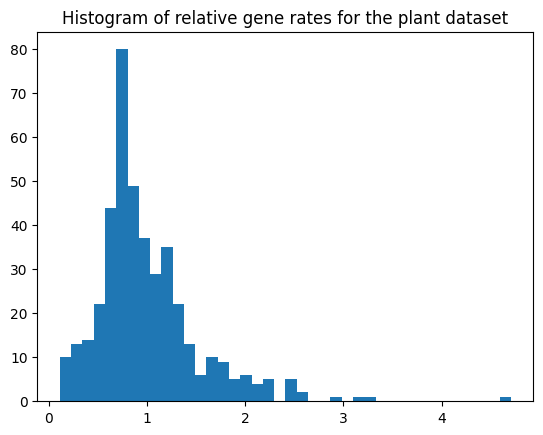

In [345]:
# Embed gene trees and species trees, infer species trees from gene trees and compare to reference
import torch
from htree.procrustes import HyperbolicProcrustes
import numpy as np

# Read species tree
st = Tree("astral-Fig3-rooted.scored.tre")

# Distance between two sets of embeddings
def compute_dist(ref,tar):
    return ref.poincare_distance(
        ref.to_poincare(ref.points),
        tar.to_poincare(tar.points[:, [tar._labels.index(label) for label in ref._labels]])).tolist()[0]

# Infer a median tree and compare it to ASTRAL
def spterr(refs,d,mm):
    m,l = refs.distance_matrix()
    with open('dist%d%s.txt' %(d,mm),'w') as f:
        f.write("%d\n%s\n" %(len(l), "\n".join("%s %s" %(l[i],"\t".join(f"{a:.6g}" for a in m[i].tolist())) for i in range(0,len(l)))))
    subprocess.run(["/Users/smirarab/miniforge3/bin/fastme", "-i", 'dist%d%s.txt' %(d,mm)],capture_output=True,text=True,check=True)
    result = subprocess.run(["compareTrees.missingBranch",  "astral-Fig3-rooted.scored.tre", "dist%d%s.txt_fastme_tree.nwk" %(d,mm)],capture_output=True,text=True,check=True)
    return result.stdout.split()[2],torch.max(m)
        
for scaled in [False, True]:
    # Read gene trees
    mt = MultiTree("Fig3-genetrees.tre")
    
    if scaled:
        # Normalize gene tree embeddings to get rid or overal rate variation
        rates = mt.normalize()
        
        #Visualize rates
        import matplotlib.pyplot as plt
        plt.hist(rates, bins=40) # Convert to numpy array
        plt.title('Histogram of relative gene rates for the plant dataset')
        
        plt.savefig("plantrates.pdf", format='pdf', bbox_inches='tight')
    
    meanres = {}
    for d in range (2,21):
        meanres[d] = []
        
        # Embed gene trees and the species tree
        me = mt.embed(dim=d, geometry='hyperbolic',precise_opt=True)
        se = st.embed(dim=d, geometry='hyperbolic',precise_opt=True,curvature=me[0].curvature)
        
        refs = me.reference_embedding(func = torch.nanmean,precise_opt=True)
        aggerror, diam = spterr(refs,d,"mean%s" %("-scaled" if scaled else "-unscaled")) 
        sd = [(aligned,unaligned) for (aligned,unaligned) in zip(compute_dist(refs, HyperbolicProcrustes(se,refs).map(se)),compute_dist(refs,se))]
        meanres[d].append(("mean", np.mean([sdi[0] for sdi in sd]),np.mean([sdi[1] for sdi in sd]),aggerror))
        
        refs = me.reference_embedding(func = torch.nanmedian,precise_opt=True)
        aggerror, diam  = spterr(refs,d,"median%s" %("-scaled" if scaled else "-unscaled")) 
        sd = [(aligned,unaligned) for (aligned,unaligned) in zip(compute_dist(refs, HyperbolicProcrustes(se,refs).map(se)),compute_dist(refs,se))]
        meanres[d].append(("median", np.mean([sdi[0] for sdi in sd]),np.mean([sdi[1] for sdi in sd]),aggerror))
    
        # A Bit of hacking needed for the Gaussian weighting method. 
        refdist, C, l = mt.distance_matrix(method = "fp")
        refs = embed_dist(dim=d, dist=refdist, labels=l, geometry='hyperbolic',precise_opt=True,curvature=me[0].curvature)
        aggerror, diam  = spterr(refs,d,"fp%s" %("-scaled" if scaled else "-unscaled")) 
        sd = [(aligned,unaligned) for (aligned,unaligned) in zip(compute_dist(refs, HyperbolicProcrustes(se,refs).map(se)),compute_dist(refs,se))]
        meanres[d].append(("FP", np.mean([sdi[0] for sdi in sd]),np.mean([sdi[1] for sdi in sd]),aggerror))
    
        print(meanres)
        
    with open('gt-dimensions-%s-fullepochs.txt2' %("scaled" if scaled else "unscaled"),'w') as f:
        f.write("Dim MeanMethod DistortionUnaligned DistortionAligned STERR\n%s" %("\n".join("%d %s %f %f %s" %(d,t[0],t[2],t[1],t[3]) for d in range(2,21) for t in meanres[d] )))

In [321]:
# Align the gene tree embeddings
import torch
me.align(func = torch.nanmean, precise_opt = 'accurate')

# Save the unaligned gene tree embeddings
me.save("1KPalignedgenetrees.aligned.embed.pickle")

In [116]:
from htree import procrustes
def align(me, reference_embedding, **kwargs) -> None:
    """
    Aligns all embeddings by averaging their distance matrices and adjusting
    each embedding to match the reference embedding.
    """
    newembds = []
    if not me.embeddings:
        me._log_info("No embeddings to align.")
        return

    filtered_kwargs = {k: v for k, v in kwargs.items() if k != 'func'}
    if me.curvature < 0:
        for i, embedding in enumerate(me.embeddings):
            model = procrustes.HyperbolicProcrustes(embedding, reference_embedding,**filtered_kwargs)
            newembds.append( model.map(embedding) )
    else:
        for i, embedding in enumerate(me.embeddings):
            model = procrustes.EuclideanProcrustes(embedding, reference_embedding,**filtered_kwargs)
            newembds.append( model.map(embedding) )

# Align gene tree embeddings to a given refs embedding
align(me,refs, precise_opt = 'accurate')

# Save the aligned gene tree embeddings
me.save("1KPalignedgenetrees.alignedotref.embed.pickle")

In [ ]:
import torch
from htree.optimizer import HyperbolicOptimizer
def hyperbolic_cost_function(points):
   #A simple cost function that minimizes the squared norm of hyperbolic points (pulling them towards the origin).
   return torch.sum((points - 1) ** 2)  # Minimize squared norm of all points
D = d

gt = mt[5]
N = st.contents.num_leaves - gt.contents.num_leaves
learning_rate = 0.01
optimizer = HyperbolicOptimizer(hyperbolic_cost_function, D, N, learning_rate=learning_rate)
optimized_points = optimizer.optimize(epochs=100)
print("Optimized Points (Adam):", optimized_points)